# Pricing European Options Using Monte Carlo Simulation

We assume that stock price $S$ follows Geometric Brownian Motion. Let $r$ be the riskless short rate and volatility $\sigma$ of the stock. Then, 

$$ S_T = S_0 \exp \left( \left( r - \frac{\sigma^2}{2} \right)T + \sigma \sqrt{T}Z \right), $$

where $S_0$ and $S_T$ are the prices of the stock at time 0 and $T$, respectively.

For a call option, the payoff is $\max(S_T - K, 0)$. 

For a put option, the payoff is $\max(K - S_T, 0)$.

In order to price a non-dividend-paying European option, we simulate the terminal price of the stock after time $T$ a certain number of times, $N$. We then calculate the payoff in each of those simulations and the mean of the payoffs, discounted by $e^{-rT}$, is the expected price of the option.

In [1]:
import numpy as np
import numpy.random as npr
import matplotlib.pylab as plt

In [2]:
'''
Calculates the value of a European call option using Monte Carlo simulation.

S0 : stock price at time 0
K : strike price
r : riskless interest rate
sigma : volatility
T : time to maturity
N : number of simulations

Returns : Value of a European call option, ndarray of simulated payoffs from the option, ndarray of simulated terminal prices of the stock price
'''

def eu_call(S0, K, r, sigma, T, N):
    z = npr.randn(N)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * z)
    payoffs = np.maximum(ST - K, 0)

    return np.exp(-r * T) * np.mean(payoffs), ST, payoffs

In [3]:
'''
Calculates the value of a European put option using Monte Carlo simulation.

S0 : stock price at time 0
K : strike price
r : riskless interest rate
sigma : volatility
T : time to maturity
N : number of simulations

Returns : Value of a European put option, ndarray of simulated payoffs from the option, ndarray of simulated terminal prices of the stock price
'''

def eu_put(S0, K, r, sigma, T, N):
    z = npr.randn(N)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * z)
    payoffs = np.maximum(K - ST, 0)

    return np.exp(-r * T) * np.mean(payoffs), ST, payoffs

Consider a call option with the following parameters:

In [4]:
S0 = 49
K = 50
r = 0.05
sigma = 0.20
T = 0.3846
N = 100000

In [5]:
option_price, terminal_prices, payoffs = eu_call(S0, K, r, sigma, T, N)

Then, the simulated terminal prices of the stock can be shown as a histogram:

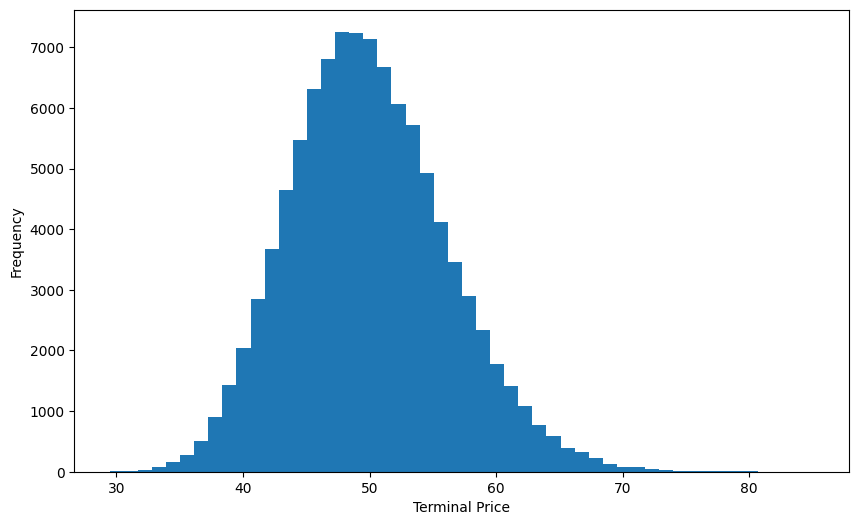

In [6]:
plt.figure(figsize=(10, 6))
plt.hist(terminal_prices, bins=50)
plt.xlabel('Terminal Price')
plt.ylabel('Frequency')
plt.show()

The payoffs from the option can be similarly shown:

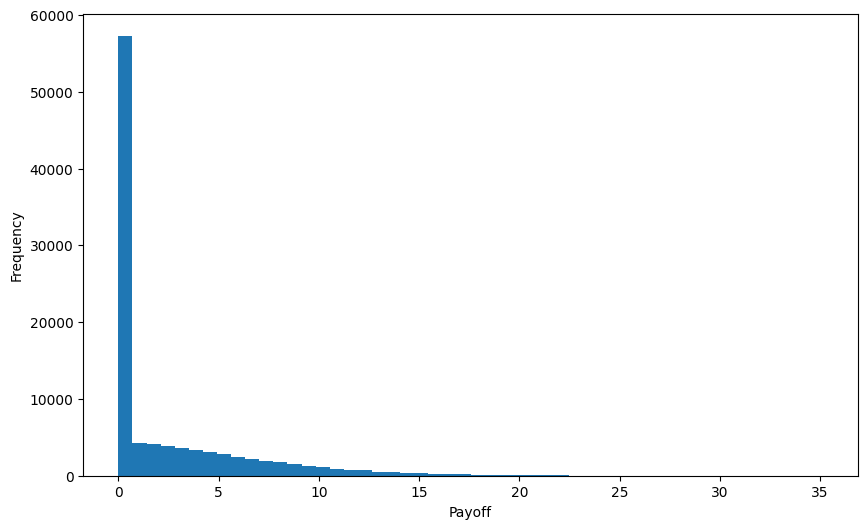

In [7]:
plt.figure(figsize=(10, 6))
plt.hist(payoffs, bins=50)
plt.xlabel('Payoff')
plt.ylabel('Frequency')
plt.show()

In [8]:
print(f"The price of the option is: ${option_price: .2f}.")

The price of the option is: $ 2.40.


We can compare this price to that obtained by the Black-Scholes-Merton pricing formulas:

In [9]:
%run bsm.py

In [12]:
bsm_price = bsm_call(S0, K, r, sigma, T)

print(f"The price of the option is: ${bsm_price: .2f}.")

The price of the option is: $ 2.40.


As the number of simulations increases, the price obtained via simulations converges to the BSM price, with random fluctuations around the theoretical price:

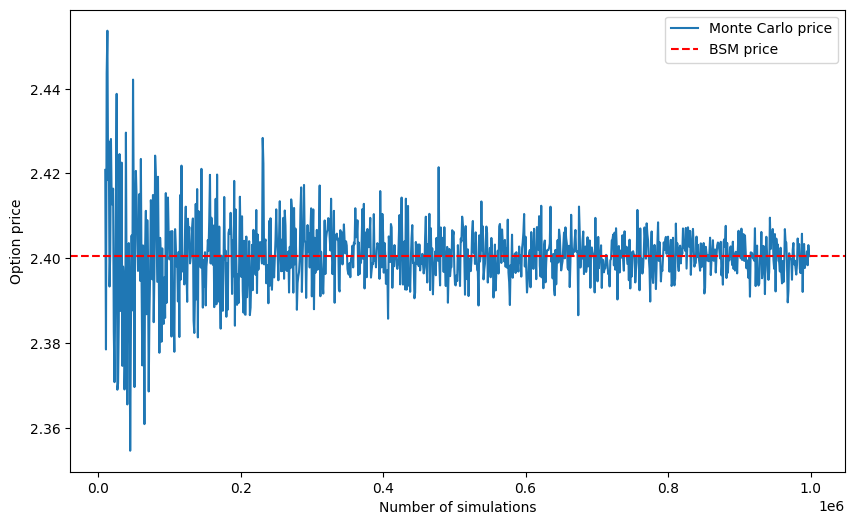

In [56]:
N = range(10000, 1000000, 1000)
mcs_prices = [eu_call(S0, K, r, sigma, T, n)[0] for n in N]

plt.figure(figsize=(10, 6))    
plt.plot(N, mcs_prices, label="Monte Carlo price")
plt.axhline(y=bsm_price, linestyle="--", color="red", label="BSM price")
plt.xlabel("Number of simulations")
plt.ylabel("Option price")
plt.legend()
plt.show()

The standard error around of the Monte Carlo estimator decreases as $1/\sqrt{N}$.